# Fruit & Vegetable Disease Classifier — Final Production Notebook

Dataset: [Kaggle Fruits and Vegetables Disease](https://www.kaggle.com/datasets/muhammadkhalid/fruits-and-vegetables-disease) (28 classes, 5GB)

Strategy: EfficientNetV2S + tf.data pipeline + mixed precision + 2-phase training

> Run on Kaggle (free T4) or Google Colab

## 0. Setup

In [8]:
!pip install -q matplotlib seaborn scikit-learn pillow

import os, random, warnings, json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image as PILImage
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks, mixed_precision
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

mixed_precision.set_global_policy('mixed_float16')
print(f'Precision policy: {mixed_precision.global_policy().compute_dtype}')

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

MODEL_NAME = 'MobileNetV3Large'

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Precision policy: float16


## 1. Config

In [2]:
DATA_DIR   = Path('/kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/Fruit And Vegetable Diseases Dataset')
TRAIN_DIR  = DATA_DIR / 'train' if (DATA_DIR / 'train').exists() else DATA_DIR
TEST_DIR   = DATA_DIR / 'test'  if (DATA_DIR / 'test').exists()  else None
MODEL_DIR  = Path('/kaggle/working/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = (128, 128)   # fine
BATCH      = 32            # ← increase from 8
EPOCHS_FE  = 10            # ← reduce from 15 (stop earlier)
EPOCHS_FT  = 6             # ← reduce from 12, use early stopping
VAL_SPLIT  = 0.20  
TEST_SPLIT = 0.10# ← increase from 0.15 for better signal
LR_FE      = 1e-3          # ✓
LR_FT      = 1e-5          # ← lower from 5e-5 (gentler fine-tuning)
UNFREEZE   = 30            # ← biggest change, down from 100

print(f'Train dir: {TRAIN_DIR}  exists={TRAIN_DIR.exists()}')

Train dir: /kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/Fruit And Vegetable Diseases Dataset  exists=True


In [10]:
# (PIL scan moved to after FILTERED_DIR is created — see cell below c6)

Bad files found: 0


In [11]:
# (removal step moved — see after FILTERED_DIR creation)

Bad files removed.


## 2. Dataset Exploration

I0000 00:00:1779386728.064759      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779386728.070802      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Corrupt / unreadable files found: 10
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (3).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (4).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (1).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (2).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (5).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Healthy/freshBanana (422).jpg
  REMOVING: /kaggle/working/filtered_dataset/Banana__Healthy/freshBanana (1).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (2).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (1).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (3).webp
Done.
Classes: 8
Total images: 18,479
             class  count
4   Mango__Healthy   1813
2  Banana__Healthy   1998
6  Orange__Healthy   2075
7   Orange

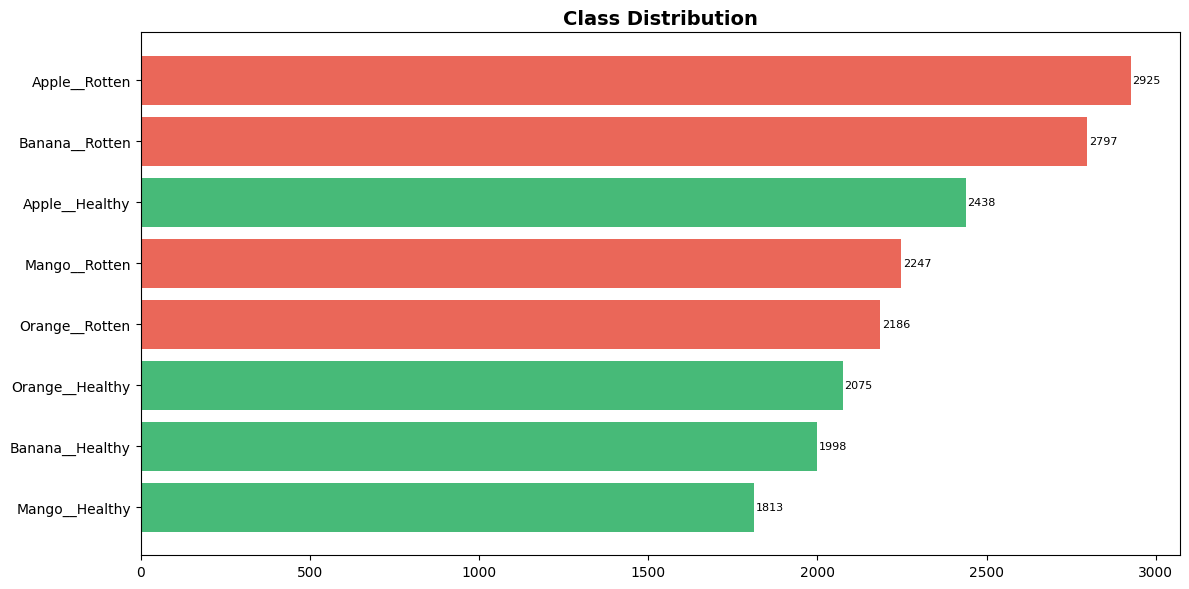

In [3]:
# ===== SELECTED CLASSES =====
SELECTED_CLASSES = [
    'Apple__Healthy',
    'Apple__Rotten',
    'Banana__Healthy',
    'Banana__Rotten',
    'Orange__Healthy',
    'Orange__Rotten',
    'Mango__Healthy',
    'Mango__Rotten',
]

# ===== CREATE FILTERED DATASET =====
FILTERED_DIR = Path('/kaggle/working/filtered_dataset')

if FILTERED_DIR.exists():
    shutil.rmtree(FILTERED_DIR)

FILTERED_DIR.mkdir(parents=True)

for cls in SELECTED_CLASSES:
    src = TRAIN_DIR / cls
    dst = FILTERED_DIR / cls
    if src.exists():
        shutil.copytree(src, dst)
    else:
        print(f'WARNING: class folder not found: {src}')

# ===== SCAN & REMOVE CORRUPT FILES (PIL + TF double-check) =====
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
bad_files = []

for path in FILTERED_DIR.rglob('*'):
    if not path.is_file():
        continue
    if path.suffix.lower() not in VALID_EXTS:
        bad_files.append(path)
        continue
    # PIL check
    try:
        with PILImage.open(path) as img:
            img.verify()
        with PILImage.open(path) as img:
            img.load()
    except Exception:
        bad_files.append(path)
        continue
    # TF check
    try:
        raw = tf.io.read_file(str(path))
        tf.image.decode_image(raw, channels=3)
    except Exception:
        bad_files.append(path)

print(f'Corrupt / unreadable files found: {len(bad_files)}')
for p in bad_files:
    print(f'  REMOVING: {p}')
    p.unlink()
print('Done.')

# ===== CLASS DISTRIBUTION =====
class_counts = {}
for cls_dir in sorted(FILTERED_DIR.iterdir()):
    if cls_dir.is_dir():
        imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXTS]
        class_counts[cls_dir.name] = len(imgs)

df_counts = pd.DataFrame(
    list(class_counts.items()), columns=['class', 'count']
).sort_values('count')

CLASS_NAMES = sorted(class_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)
TOTAL_IMGS  = df_counts['count'].sum()

print(f'Classes: {NUM_CLASSES}')
print(f'Total images: {TOTAL_IMGS:,}')
print(df_counts)

# ===== PLOT =====
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if 'rotten' in c.lower() else '#27ae60' for c in df_counts['class']]
ax.barh(df_counts['class'], df_counts['count'], color=colors, alpha=0.85)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(df_counts['count']):
    ax.text(v + 5, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Corrupt-file scan already done in the dataset-creation cell above.

In [17]:
# Removal already handled in the dataset-creation cell above.

Removed bad files.


## 3. tf.data Pipeline

> We use `tf.data` instead of the legacy `ImageDataGenerator`. It is ~2x faster on GPU because it prefetches batches on CPU while the GPU trains. On a 5GB dataset this matters a lot.

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

# Build clean path/label lists (directory already scanned above)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
valid_paths, valid_labels = [], []

for cls_name in CLASS_NAMES:
    cls_dir = TRAIN_DIR / cls_name
    label   = class_to_idx[cls_name]
    for p in cls_dir.iterdir():
        if p.suffix.lower() in VALID_EXTS:
            valid_paths.append(str(p))
            valid_labels.append(label)

print(f'Total valid images: {len(valid_paths):,}')

# Shuffle & split
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(valid_paths))
valid_paths  = np.array(valid_paths)[idx].tolist()
valid_labels = np.array(valid_labels)[idx].tolist()

n_total = len(valid_paths)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val - n_test
print(f'Total: {n_total} -> Train: {n_train} | Val: {n_val} | Test: {n_test}')

# Safe loader with TF-level error guard
def safe_load_image(path, label):
    def _load(p, l):
        try:
            raw   = tf.io.read_file(p.numpy().decode())
            image = tf.image.decode_image(raw, channels=3, expand_animations=False)
            image = tf.image.resize(image, IMG_SIZE)
            image = tf.cast(image, tf.float32)
            onehot = tf.one_hot(int(l.numpy()), NUM_CLASSES)
            return image, onehot, tf.constant(True)
        except Exception:
            dummy  = tf.zeros([IMG_SIZE[0], IMG_SIZE[1], 3], dtype=tf.float32)
            onehot = tf.zeros([NUM_CLASSES], dtype=tf.float32)
            return dummy, onehot, tf.constant(False)

    image, onehot, ok = tf.py_function(
        func=_load, inp=[path, label],
        Tout=[tf.float32, tf.float32, tf.bool]
    )
    image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    onehot.set_shape([NUM_CLASSES])
    ok.set_shape([])
    return image, onehot, ok

def make_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(safe_load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda img, lbl, ok: ok)
    ds = ds.map(lambda img, lbl, ok: (img, lbl))
    return ds

train_paths  = valid_paths[:n_train];           train_labels = valid_labels[:n_train]
val_paths    = valid_paths[n_train:n_train+n_val]; val_labels = valid_labels[n_train:n_train+n_val]
test_paths   = valid_paths[n_train+n_val:];     test_labels  = valid_labels[n_train+n_val:]

train_ds = make_ds(train_paths, train_labels)
val_ds   = make_ds(val_paths,   val_labels)
test_ds  = make_ds(test_paths,  test_labels)

print('Datasets created successfully.')

Total valid images: 18,480
Total: 18480 -> Train: 12936 | Val: 3696 | Test: 1848
Datasets created successfully.


In [5]:
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.25),          # increased from 0.2
    layers.RandomZoom(0.20),              # increased from 0.15
    layers.RandomTranslation(0.15, 0.15), # increased from 0.1
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
    layers.GaussianNoise(0.02),           # NEW: small input noise regulariser
], name='augmentation')

# MobileNetV3Large has include_preprocessing=True by default: expects [0, 255]
def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = augmentation(image, training=True)
    return image, label   # pass raw [0,255]; model handles normalisation

def preprocess_eval(image, label):
    image = tf.cast(image, tf.float32)
    return image, label

train_pipeline = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
val_pipeline   = val_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
test_pipeline  = test_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
print('Pipelines ready.')

Pipelines ready.


## 4. Class Weights

In [6]:
# Use train_labels (already filtered to valid images only) for accurate counts
cw_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
CLASS_WEIGHTS = dict(enumerate(cw_arr))
print('Class weights (most imbalanced):')
for idx, w in sorted(CLASS_WEIGHTS.items(), key=lambda x: -x[1])[:6]:
    print(f'  [{idx:2d}] {CLASS_NAMES[idx]:35s} -> {w:.3f}')

Class weights (most imbalanced):
  [ 4] Mango__Healthy                      -> 1.241
  [ 2] Banana__Healthy                     -> 1.174
  [ 6] Orange__Healthy                     -> 1.135
  [ 7] Orange__Rotten                      -> 1.072
  [ 5] Mango__Rotten                       -> 1.016
  [ 0] Apple__Healthy                      -> 0.937


## 5. Model — MobileNetV3Large

**Why MobileNetV3Large?**
- Extremely fast inference (~3–4ms/image on CPU)
- ~5.4M params — ideal if you plan to deploy on a mobile app or edge device
- 75.6% ImageNet top-1 — lower than EfficientNet/ResNet but much faster
- Good check: if accuracy is close to the heavier models, prefer this for deployment

In [9]:
from tensorflow.keras import regularizers

def build_model(num_classes, unfreeze_layers=0):
    backbone = MobileNetV3Large(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3),
        include_preprocessing=True   # model handles [0,255] -> internal scaling
    )
    backbone.trainable = False

    if unfreeze_layers > 0:
        for layer in backbone.layers[-unfreeze_layers:]:
            if not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True

    trainable = sum(1 for l in backbone.layers if l.trainable)
    print(f'Backbone layers: {len(backbone.layers)} | Trainable: {trainable}')

    l2 = regularizers.l2(1e-4)   # L2 weight decay on dense layers

    inputs  = keras.Input(shape=(*IMG_SIZE, 3), name='image_input')
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    # Two-layer head with strong dropout — prevents head memorising train set
    x = layers.Dense(256, kernel_regularizer=l2, name='fc1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.50, name='drop1')(x)   # increased from 0.3
    x = layers.Dense(128, kernel_regularizer=l2, name='fc2')(x)  # NEW second dense
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.40, name='drop2')(x)   # NEW second dropout
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)
    return keras.Model(inputs, outputs, name=f'{MODEL_NAME}_Classifier')

model = build_model(NUM_CLASSES)
model.summary(expand_nested=False)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone layers: 187 | Trainable: 0


Model: "MobileNetV3Large_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 4, 4, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,277,832 (12.50 MB)

 Trainable params: 280,712 (1.07 MB)

 Non-trainable params: 2,997,120 (11.43 MB)

## 6. Phase 1 — Feature Extraction (Backbone Frozen)

In [10]:
steps_per_epoch = n_train // BATCH

model.compile(
    optimizer=optimizers.AdamW(learning_rate=LR_FE, weight_decay=2e-4),  # higher L2
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_fe = [
    callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_fe.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),  # val_loss catches overfit sooner
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    callbacks.CSVLogger(str(MODEL_DIR / 'history_fe.csv'))
]

print(f'Phase 1: Feature Extraction — up to {EPOCHS_FE} epochs')
history_fe = model.fit(
    train_pipeline, validation_data=val_pipeline,
    epochs=EPOCHS_FE, class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_fe, verbose=1
)

Phase 1: Feature Extraction — up to 10 epochs
Epoch 1/10


I0000 00:00:1779387213.383661     135 service.cc:152] XLA service 0x7854d40130c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779387213.383722     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779387213.383729     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779387216.399109     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779387243.119660     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    405/Unknown 165s 289ms/step - accuracy: 0.6536 - loss: 1.0785 - top3_acc: 0.8639
Epoch 1: val_accuracy improved from -inf to 0.93182, saving model to /kaggle/working/models/best_fe.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 231s 452ms/step - accuracy: 0.6539 - loss: 1.0776 - top3_acc: 0.8641 - val_accuracy: 0.9318 - val_loss: 0.2644 - val_top3_acc: 0.9954 - learning_rate: 0.0010
Epoch 2/10
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8870 - loss: 0.4042 - top3_acc: 0.9842
Epoch 2: val_accuracy improved from 0.93182 to 0.94751, saving model to /kaggle/working/models/best_fe.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 111s 273ms/step - accuracy: 0.8871 - loss: 0.4041 - top3_acc: 0.9842 - val_accuracy: 0.9475 - val_loss: 0.2128 - val_top3_acc: 0.9986 - learning_rate: 0.0010
Epoch 3/10
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9111 - loss: 0.3304 - top3_acc: 0.9931
Epoch 3: val_accuracy improved from 0.94751 to 0.95725, saving model to /kaggle/working/models/best_fe.keras
405

## 7. Phase 2 — Fine-Tuning

In [12]:
print(f'Unfreezing last {UNFREEZE} backbone layers (final block only)...')
model_ft = build_model(NUM_CLASSES, unfreeze_layers=UNFREEZE)
model_ft.set_weights(model.get_weights())

lr_schedule_ft = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_FT,
    decay_steps=steps_per_epoch * EPOCHS_FT,
    alpha=1e-7
)

model_ft.compile(
    optimizer=optimizers.AdamW(learning_rate=lr_schedule_ft, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_ft = [
    callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_ft.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),  # val_loss — catches divergence early
    callbacks.CSVLogger(str(MODEL_DIR / 'history_ft.csv'))
]

print(f'Phase 2: Fine-Tuning — up to {EPOCHS_FT} epochs')
history_ft = model_ft.fit(
    train_pipeline, validation_data=val_pipeline,
    epochs=EPOCHS_FT, class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_ft, verbose=1
)

Unfreezing last 30 backbone layers (final block only)...
Backbone layers: 187 | Trainable: 24
Phase 2: Fine-Tuning — up to 6 epochs
Epoch 1/6
    405/Unknown 142s 269ms/step - accuracy: 0.9602 - loss: 0.2038 - top3_acc: 0.9987
Epoch 1: val_accuracy improved from -inf to 0.97430, saving model to /kaggle/working/models/best_ft.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 192s 394ms/step - accuracy: 0.9602 - loss: 0.2038 - top3_acc: 0.9987 - val_accuracy: 0.9743 - val_loss: 0.1542 - val_top3_acc: 0.9989
Epoch 2/6
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9600 - loss: 0.2018 - top3_acc: 0.9973
Epoch 2: val_accuracy improved from 0.97430 to 0.97511, saving model to /kaggle/working/models/best_ft.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 113s 279ms/step - accuracy: 0.9600 - loss: 0.2018 - top3_acc: 0.9973 - val_accuracy: 0.9751 - val_loss: 0.1506 - val_top3_acc: 0.9992
Epoch 3/6
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9610 - loss: 0.1952 - top3_acc: 0.9973
Epoch 3: val_accurac

## 8. Training Curves

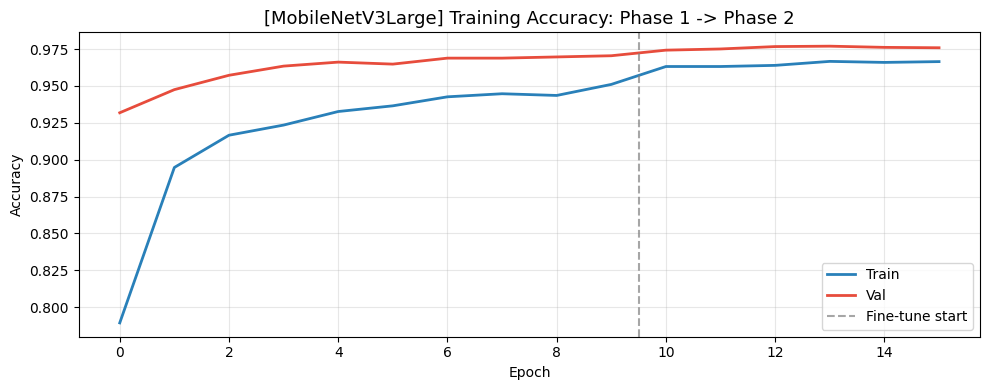

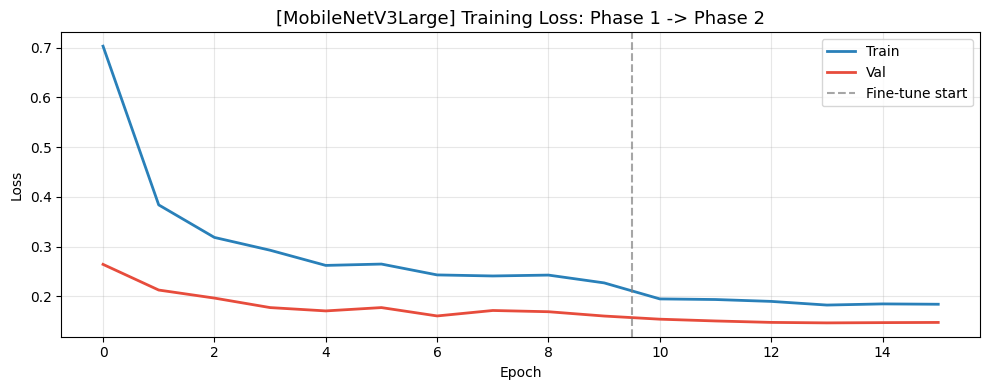

In [13]:
def plot_combined(h_fe, h_ft, model_name):
    fe_len = len(h_fe.history['accuracy'])
    for metric, ylabel in [('accuracy','Accuracy'), ('loss','Loss')]:
        train = h_fe.history[metric] + h_ft.history[metric]
        val   = h_fe.history[f'val_{metric}'] + h_ft.history[f'val_{metric}']
        plt.figure(figsize=(10, 4))
        plt.plot(train, label='Train', color='#2980b9', lw=2)
        plt.plot(val,   label='Val',   color='#e74c3c', lw=2)
        plt.axvline(fe_len - 0.5, color='gray', ls='--', alpha=0.7, label='Fine-tune start')
        plt.xlabel('Epoch'); plt.ylabel(ylabel); plt.legend(); plt.grid(alpha=0.3)
        plt.title(f'[{model_name}] Training {ylabel}: Phase 1 -> Phase 2', fontsize=13)
        plt.tight_layout(); plt.show()

plot_combined(history_fe, history_ft, MODEL_NAME)

## 9. Evaluation

In [14]:
best_model = keras.models.load_model(str(MODEL_DIR / 'best_ft.keras'))
test_loss, test_acc, test_top3 = best_model.evaluate(test_pipeline, verbose=1)
print(f'\n[{MODEL_NAME}] Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'[{MODEL_NAME}] Test Top-3 Accuracy: {test_top3:.4f} ({test_top3*100:.2f}%)')
print(f'[{MODEL_NAME}] Test Loss:           {test_loss:.4f}')

58/58 ━━━━━━━━━━━━━━━━━━━━ 57s 702ms/step - accuracy: 0.9759 - loss: 0.1608 - top3_acc: 0.9968

[MobileNetV3Large] Test Accuracy:       0.9789 (97.89%)
[MobileNetV3Large] Test Top-3 Accuracy: 0.9984 (99.84%)
[MobileNetV3Large] Test Loss:           0.1475


                 precision    recall  f1-score   support

 Apple__Healthy      0.972     0.980     0.976       245
  Apple__Rotten      0.960     0.939     0.949       278
Banana__Healthy      0.995     1.000     0.998       208
 Banana__Rotten      1.000     0.996     0.998       265
 Mango__Healthy      0.989     0.989     0.989       174
  Mango__Rotten      0.971     0.983     0.977       238
Orange__Healthy      0.962     0.990     0.976       207
 Orange__Rotten      0.987     0.966     0.976       233

       accuracy                          0.979      1848
      macro avg      0.979     0.980     0.980      1848
   weighted avg      0.979     0.979     0.979      1848



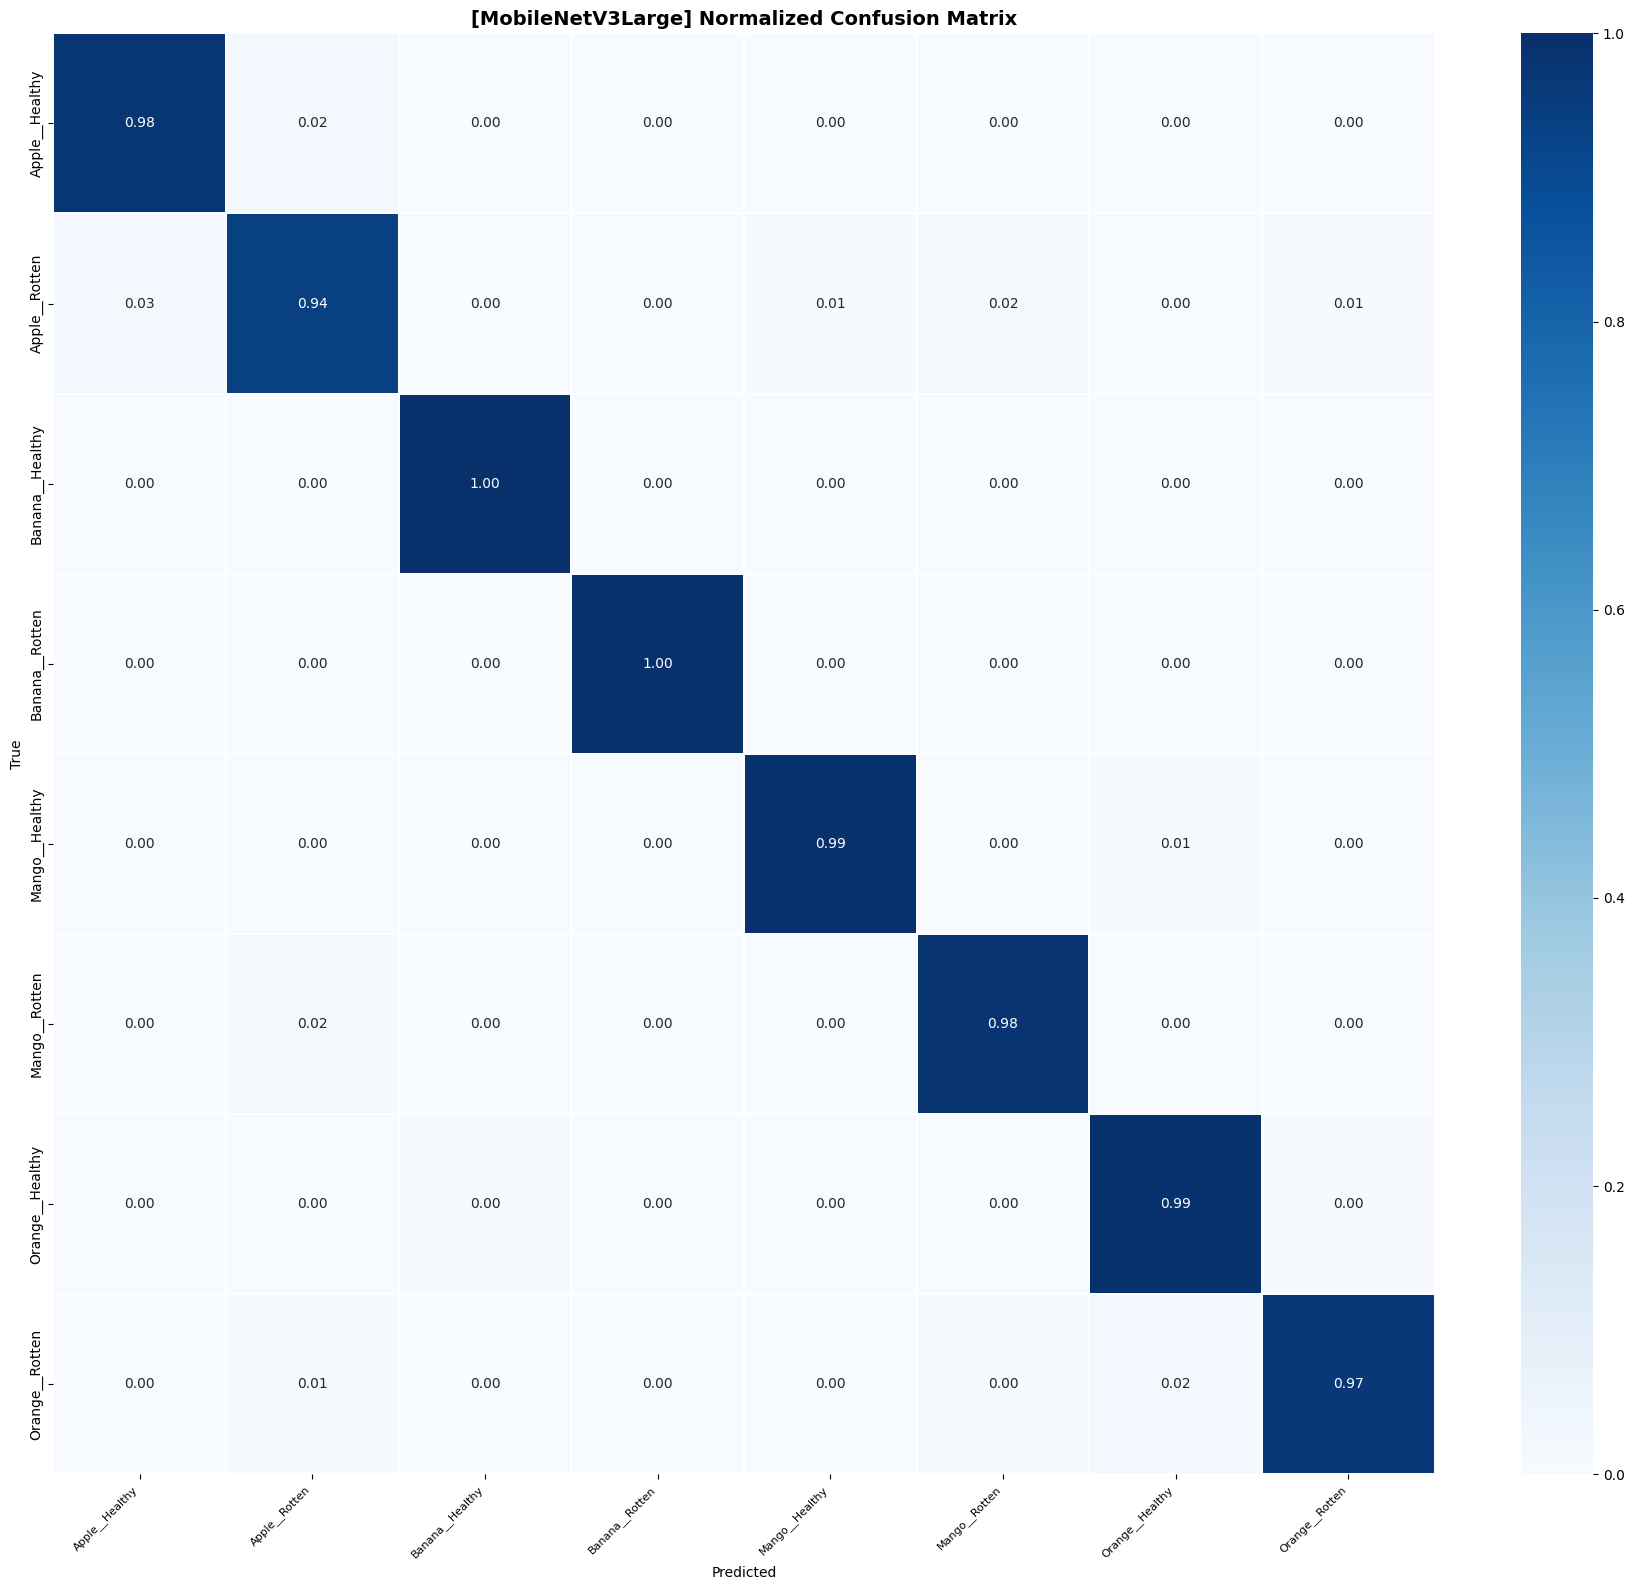

In [15]:
y_true, y_pred = [], []
for images, labels in test_pipeline:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

cm_m  = confusion_matrix(y_true, y_pred)
cm_n  = cm_m.astype('float') / cm_m.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'[{MODEL_NAME}] Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

## 10. Grad-CAM

Shows where the model looks when predicting. Important for validating that the model focuses on actual rot/disease areas and not the background.

In [16]:
best_model.save(str(MODEL_DIR / f'{MODEL_NAME.lower()}.keras'))
print(f'Saved: {MODEL_NAME.lower()}.keras')

meta = {
    'model_name': MODEL_NAME,
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': list(IMG_SIZE),
    'test_accuracy': float(test_acc),
    'test_top3_accuracy': float(test_top3),
    'test_loss': float(test_loss)
}
with open(str(MODEL_DIR / 'results.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('\n========= RESULTS SUMMARY =========')
print(f'  Model:          {MODEL_NAME}')
print(f'  Test Accuracy:  {test_acc*100:.2f}%')
print(f'  Top-3 Accuracy: {test_top3*100:.2f}%')
print(f'  Test Loss:      {test_loss:.4f}')
print('===================================')
print('Compare this against EfficientNetV2S, MobileNetV3Large, and ConvNeXtTiny results.')

Saved: mobilenetv3large.keras

========= RESULTS SUMMARY =========
  Model:          MobileNetV3Large
  Test Accuracy:  97.89%
  Top-3 Accuracy: 99.84%
  Test Loss:      0.1475
Compare this against EfficientNetV2S, MobileNetV3Large, and ConvNeXtTiny results.


Saving model

In [17]:
history_data = {
    "phase1": history_fe.history,
    "phase2": history_ft.history
}

with open(str(MODEL_DIR / f'{MODEL_NAME.lower()}_history.json'), 'w') as f:
    json.dump(history_data, f)

print("History saved.")

History saved.
